# Part 3: Getting Started with AnnData

## Overview

This notebook explores the **AnnData** (Annotated Data) format using the PBMC dataset that was analyzed in Part 2. AnnData is the standard data structure for single-cell analysis in Python and is used by the entire **scverse** ecosystem (Scanpy, scVI, etc.).

### Data Origin
- **Input**: `pbmc_chrX_analyzed.h5ad` (output from Part 2)
- **Content**: 252 PBMC cells × chrX genes, fully analyzed
- **Includes**: Raw counts, normalized counts, PCA, UMAP, Leiden clusters, cell type annotations

### What We Cover
1. Loading an h5ad file
2. AnnData structure: X, obs, var, obsm, varm, layers, uns, obsp
3. Subsetting AnnData objects
4. Adding and modifying metadata
5. Working with layers
6. Views vs copies
7. Writing and reading h5ad files
8. Visualizing the data structure

### References
- [Getting started with anndata](https://anndata.readthedocs.io/en/latest/tutorials/notebooks/getting-started.html)
- [scverse AnnData getting started](https://scverse-tutorials.readthedocs.io/en/latest/notebooks/anndata_getting_started.html)


## Step 0: Install Required Packages

In [1]:
!pip install anndata scanpy numpy pandas scipy matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 131.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


## Step 1: Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
from scipy.sparse import csr_matrix

sc.settings.set_figure_params(dpi=80, facecolor='white')

print('AnnData version:', ad.__version__)
print('Scanpy version:', sc.__version__)
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)

AnnData version: 0.12.10
Scanpy version: 1.12.1
NumPy version: 2.0.2
Pandas version: 2.3.3


## Step 2: Upload the h5ad File from Part 2

Upload the file `pbmc_chrX_analyzed.h5ad` that was saved at the end of Part 2.

In [3]:
# Upload h5ad file (Google Colab only)
try:
    from google.colab import files
    print('Please upload the file: pbmc_chrX_analyzed.h5ad')
    uploaded = files.upload()
    h5ad_file = list(uploaded.keys())[0]
    print(f'Uploaded: {h5ad_file}')
except ImportError:
    h5ad_file = 'pbmc_chrX_analyzed.h5ad'
    print(f'Running locally. Using file: {h5ad_file}')

Please upload the file: pbmc_chrX_analyzed.h5ad


Saving pbmc_chrX_analyzed.h5ad to pbmc_chrX_analyzed.h5ad
Uploaded: pbmc_chrX_analyzed.h5ad


## Step 3: Loading AnnData from Disk

AnnData uses the **h5ad** format — a HDF5-based file format that efficiently stores all components of the annotated data object.

Given a path to a `.h5ad` file, `read_h5ad()` loads it into Python and creates our AnnData object.

In [4]:
# Load the analyzed PBMC AnnData from Part 2
adata = ad.read_h5ad(h5ad_file)

print('AnnData loaded successfully!')
print()
print(adata)

AnnData loaded successfully!

AnnData object with n_obs × n_vars = 252 × 751
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.10', 'leiden_res_0.30', 'leiden_res_0.50', 'leiden', 'cell_type'
    var: 'gene_ids', 'gene_names', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'hvg', 'leiden_colors', 'leiden_res_0.10', 'leiden_res_0.10_colors', 'leiden_res_0.30', 'leiden_res_0.30_colors', 'leiden_res_0.50', 'leiden_res_0.50_colors', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rank_genes_groups', 'scruble

In [5]:
# Overview of the AnnData object
print('=' * 55)
print('AnnData Structure Overview')
print('=' * 55)
print(f'Shape:          {adata.shape}  (cells × genes)')
print(f'Cells (obs):    {adata.n_obs}')
print(f'Genes (var):    {adata.n_vars}')
print()
print(f'obs columns:    {list(adata.obs.columns)}')
print(f'var columns:    {list(adata.var.columns)}')
print(f'obsm keys:      {list(adata.obsm.keys())}')
print(f'layers keys:    {list(adata.layers.keys())}')
print(f'uns keys:       {list(adata.uns.keys())}')

AnnData Structure Overview
Shape:          (252, 751)  (cells × genes)
Cells (obs):    252
Genes (var):    751

obs columns:    ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.10', 'leiden_res_0.30', 'leiden_res_0.50', 'leiden', 'cell_type']
var columns:    ['gene_ids', 'gene_names', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm']
obsm keys:      ['X_pca', 'X_umap']
layers keys:    ['counts', 'log_normalized']
uns keys:       ['cell_type_colors', 'hvg', 'leiden_colors', 'leiden_res_0.10', 'leiden_res_0.10_colors', 'leiden_res_0.30', 'leiden_res_0.3

## Step 4: The Core Data Matrix — `adata.X`

The `adata.X` slot holds the **active data matrix** used for analysis. In our case it contains the **log-normalized gene expression counts**.

- Rows = cells (observations)
- Columns = genes (variables)
- Stored as a **sparse matrix** to save memory (most values are zero)

In [6]:
# Inspect the main data matrix
print('Active data matrix (adata.X):')
print(f'  Type:   {type(adata.X)}')
print(f'  Shape:  {adata.X.shape}')
print(f'  Dtype:  {adata.X.dtype}')
print()

# Sparsity
total_elements = adata.X.shape[0] * adata.X.shape[1]
non_zero = adata.X.nnz
sparsity = 1 - (non_zero / total_elements)
print(f'  Non-zero entries:  {non_zero:,}')
print(f'  Total elements:    {total_elements:,}')
print(f'  Sparsity:          {sparsity:.1%}')
print(f'  (Only {1-sparsity:.1%} of entries are non-zero!)')

Active data matrix (adata.X):
  Type:   <class 'scipy.sparse._csr.csr_matrix'>
  Shape:  (252, 751)
  Dtype:  float32

  Non-zero entries:  38,710
  Total elements:    189,252
  Sparsity:          79.5%
  (Only 20.5% of entries are non-zero!)


In [7]:
# Look at a small slice of the data matrix (convert to dense for display)
print('First 5 cells × first 5 genes (log-normalized counts):')
print()
slice_data = adata.X[:5, :5].toarray()
slice_df = pd.DataFrame(
    slice_data,
    index=adata.obs_names[:5],
    columns=adata.var_names[:5]
)
print(slice_df.round(3))

First 5 cells × first 5 genes (log-normalized counts):

                  PLCXD1  GTPBP6  LINC00685  PPP2R3B  SHOX
AAAGAACCAATGGCAG     0.0   0.000      0.000      0.0   0.0
AAAGGATAGTAGACAT     0.0   0.528      0.000      0.0   0.0
AAAGGATCACCGGCTA     0.0   0.000      0.000      0.0   0.0
AAAGGATTCCGTTTCG     0.0   0.486      0.486      0.0   0.0
AAAGTCCCACCAGCCA     0.0   0.387      0.000      0.0   0.0


## Step 5: Cell Annotations — `adata.obs`

`adata.obs` is a **Pandas DataFrame** where each row corresponds to a cell. It stores all cell-level metadata such as QC metrics, cluster assignments, and cell type labels.

The **index** of `adata.obs` is the unique cell identifier — in our case, the 10X barcode sequence.

In [8]:
# Inspect cell annotations
print('Cell annotations (adata.obs):')
print(f'Shape: {adata.obs.shape}')
print()
print(adata.obs.head(10))

Cell annotations (adata.obs):
Shape: (252, 19)

                  n_genes_by_counts  log1p_n_genes_by_counts  total_counts  \
AAAGAACCAATGGCAG                105                 4.663439           326   
AAAGGATAGTAGACAT                152                 5.030438          1495   
AAAGGATCACCGGCTA                124                 4.828314           845   
AAAGGATTCCGTTTCG                208                 5.342334          1663   
AAAGTCCCACCAGCCA                202                 5.313206          2196   
AAATGGAAGCCGCTTG                224                 5.416100          1570   
AACGAAACAGCGTTTA                116                 4.762174           482   
AACGTCAAGACGCCCT                171                 5.147494          1125   
AAGAACAAGACCATTC                119                 4.787492           755   
AAGCGTTTCGCTATTT                148                 5.003946          1154   

                  log1p_total_counts  pct_counts_in_top_50_genes  \
AAAGAACCAATGGCAG         

In [9]:
# Cell barcodes (index = unique cell identifiers from 10X)
print('Cell barcodes (obs_names):')
print(adata.obs_names[:10].tolist())
print(f'...and {adata.n_obs - 10} more')

Cell barcodes (obs_names):
['AAAGAACCAATGGCAG', 'AAAGGATAGTAGACAT', 'AAAGGATCACCGGCTA', 'AAAGGATTCCGTTTCG', 'AAAGTCCCACCAGCCA', 'AAATGGAAGCCGCTTG', 'AACGAAACAGCGTTTA', 'AACGTCAAGACGCCCT', 'AAGAACAAGACCATTC', 'AAGCGTTTCGCTATTT']
...and 242 more


In [10]:
# Count cells per cluster and cell type
print('Cells per Leiden cluster:')
print(adata.obs['leiden'].value_counts().sort_index())
print()
print('Cells per cell type:')
print(adata.obs['cell_type'].value_counts())

Cells per Leiden cluster:
leiden
0    173
1     79
Name: count, dtype: int64

Cells per cell type:
cell_type
T/NK Lymphocytes    173
B Lymphocytes        79
Name: count, dtype: int64


In [11]:
# Add a new cell annotation: flag high ribosomal content cells
ribo_threshold = adata.obs['pct_counts_ribo'].quantile(0.75)
adata.obs['high_ribo'] = adata.obs['pct_counts_ribo'] > ribo_threshold

print(f'Ribosomal content threshold (75th percentile): {ribo_threshold:.2f}%')
print(f'High ribosomal cells: {adata.obs["high_ribo"].sum()}')
print(f'Low ribosomal cells:  {(~adata.obs["high_ribo"]).sum()}')
print()
print('Updated obs columns:', list(adata.obs.columns))

Ribosomal content threshold (75th percentile): 55.30%
High ribosomal cells: 63
Low ribosomal cells:  189

Updated obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.10', 'leiden_res_0.30', 'leiden_res_0.50', 'leiden', 'cell_type', 'high_ribo']


## Step 6: Gene Annotations — `adata.var`

`adata.var` is a **Pandas DataFrame** where each row corresponds to a gene. It stores gene-level metadata like gene IDs, names, and flags for highly variable genes.

In [12]:
# Inspect gene annotations
print('Gene annotations (adata.var):')
print(f'Shape: {adata.var.shape}')
print()
print(adata.var.head(10))

Gene annotations (adata.var):
Shape: (751, 14)

                  gene_ids gene_names   ribo  n_cells_by_counts  mean_counts  \
PLCXD1     ENSG00000182378     PLCXD1  False                 20     0.083333   
GTPBP6     ENSG00000178605     GTPBP6  False                 61     0.285714   
LINC00685  ENSG00000226179  LINC00685  False                 28     0.126984   
PPP2R3B    ENSG00000167393    PPP2R3B  False                 43     0.182540   
SHOX       ENSG00000185960       SHOX  False                 10     0.039683   
RPL14P5    ENSG00000225661    RPL14P5   True                234     4.277778   
CSF2RA     ENSG00000198223     CSF2RA  False                 84     0.503968   
RN7SL355P  ENSG00000265350  RN7SL355P  False                  9     0.035714   
IL3RA      ENSG00000185291      IL3RA  False                 10     0.107143   
SLC25A6    ENSG00000169100    SLC25A6  False                233     4.543651   

           log1p_mean_counts  pct_dropout_by_counts  total_counts  \
PL

In [13]:
# Gene names (var_names = index)
print('Gene names (var_names):')
print(adata.var_names[:10].tolist())
print(f'...and {adata.n_vars - 10} more')
print()

# Show highly variable genes info
if 'highly_variable' in adata.var.columns:
    n_hvg = adata.var['highly_variable'].sum()
    print(f'Highly variable genes: {n_hvg} out of {adata.n_vars}')
    print('Top 10 HVGs by dispersion:')
    hvg = adata.var[adata.var['highly_variable']].sort_values('dispersions_norm', ascending=False)
    print(hvg.head(10)[['gene_ids', 'dispersions_norm']])

Gene names (var_names):
['PLCXD1', 'GTPBP6', 'LINC00685', 'PPP2R3B', 'SHOX', 'RPL14P5', 'CSF2RA', 'RN7SL355P', 'IL3RA', 'SLC25A6']
...and 741 more

Highly variable genes: 500 out of 751
Top 10 HVGs by dispersion:
                  gene_ids  dispersions_norm
TSPYL2     ENSG00000184205          4.930963
IL3RA      ENSG00000185291          3.407915
SH2D1A     ENSG00000183918          3.253045
LINC00892  ENSG00000233093          3.001204
RNU2-68P   ENSG00000222810          2.773499
HCCS       ENSG00000004961          2.701683
CSTF2      ENSG00000101811          2.689840
FAM58A     ENSG00000147382          2.669911
CFP        ENSG00000126759          2.654906
CYBB       ENSG00000165168          2.607136


In [14]:
# Access a specific gene's metadata
example_gene = adata.var_names[0]
print(f'Metadata for gene "{example_gene}":')
print(adata.var.loc[example_gene])

Metadata for gene "PLCXD1":
gene_ids                 ENSG00000182378
gene_names                        PLCXD1
ribo                               False
n_cells_by_counts                     20
mean_counts                     0.083333
log1p_mean_counts               0.080043
pct_dropout_by_counts          92.063492
total_counts                          21
log1p_total_counts              3.091042
n_cells                               20
highly_variable                     True
means                           0.084546
dispersions                     0.425423
dispersions_norm                0.627194
Name: PLCXD1, dtype: object


## Step 7: Multi-dimensional Embeddings — `adata.obsm`

`adata.obsm` stores **multi-dimensional arrays** for each cell, such as PCA and UMAP embeddings. Each matrix must have the same number of rows as cells (`n_obs`).

In [15]:
# Inspect obsm
print('Multi-dimensional cell representations (adata.obsm):')
for key in adata.obsm:
    shape = adata.obsm[key].shape
    print(f'  {key}: shape = {shape}')

Multi-dimensional cell representations (adata.obsm):
  X_pca: shape = (252, 50)
  X_umap: shape = (252, 2)


In [16]:
# Look at PCA coordinates for first 5 cells
print('PCA coordinates for first 5 cells (first 3 PCs):')
pca_df = pd.DataFrame(
    adata.obsm['X_pca'][:5, :3],
    index=adata.obs_names[:5],
    columns=['PC1', 'PC2', 'PC3']
)
print(pca_df.round(4))

PCA coordinates for first 5 cells (first 3 PCs):
                     PC1     PC2     PC3
AAAGAACCAATGGCAG -0.9848  3.0696  2.3816
AAAGGATAGTAGACAT -2.0650 -1.5160  0.5471
AAAGGATCACCGGCTA -1.9880 -1.5364 -0.8044
AAAGGATTCCGTTTCG  3.6262 -0.4807  0.9270
AAAGTCCCACCAGCCA -1.0071 -0.2777 -0.3916


In [17]:
# Look at UMAP coordinates for first 5 cells
print('UMAP coordinates for first 5 cells:')
umap_df = pd.DataFrame(
    adata.obsm['X_umap'][:5, :],
    index=adata.obs_names[:5],
    columns=['UMAP1', 'UMAP2']
)
print(umap_df.round(4))

UMAP coordinates for first 5 cells:
                      UMAP1    UMAP2
AAAGAACCAATGGCAG  19.336500   1.9986
AAAGGATAGTAGACAT  21.002001   6.2876
AAAGGATCACCGGCTA  19.856001   7.0598
AAAGGATTCCGTTTCG  -0.201700  12.0330
AAAGTCCCACCAGCCA  18.446600   5.9026


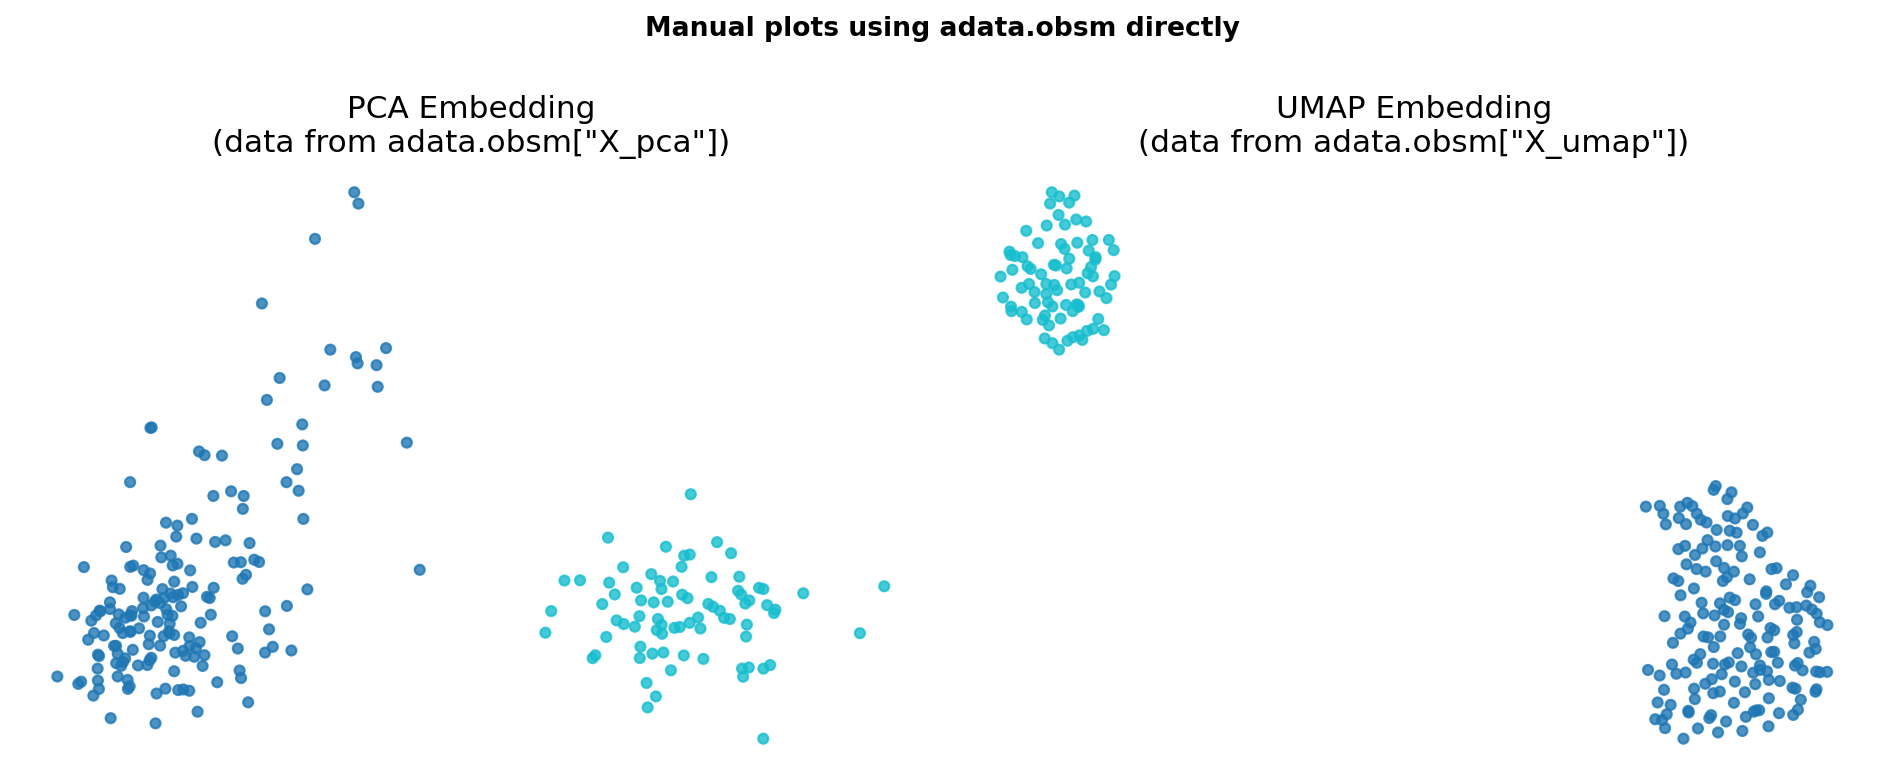

Plot saved as embeddings_plot.png


In [18]:
# Manual UMAP plot using raw obsm data (to demonstrate how embeddings are stored)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PCA plot (first 2 PCs)
scatter1 = axes[0].scatter(
    x=adata.obsm['X_pca'][:, 0],
    y=adata.obsm['X_pca'][:, 1],
    c=pd.Categorical(adata.obs['leiden']).codes,
    cmap='tab10',
    s=20,
    alpha=0.8
)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA Embedding\n(data from adata.obsm["X_pca"])')
axes[0].axis('off')

# UMAP plot
scatter2 = axes[1].scatter(
    x=adata.obsm['X_umap'][:, 0],
    y=adata.obsm['X_umap'][:, 1],
    c=pd.Categorical(adata.obs['leiden']).codes,
    cmap='tab10',
    s=20,
    alpha=0.8
)
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
axes[1].set_title('UMAP Embedding\n(data from adata.obsm["X_umap"])')
axes[1].axis('off')

plt.suptitle('Manual plots using adata.obsm directly', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('embeddings_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as embeddings_plot.png')

In [19]:
# Add a new embedding to obsm — random 3D coordinates for demonstration
np.random.seed(42)
adata.obsm['X_random_3d'] = np.random.normal(0, 1, size=(adata.n_obs, 3))

print('New embedding added to obsm!')
print('Updated obsm keys:', list(adata.obsm.keys()))

New embedding added to obsm!
Updated obsm keys: ['X_pca', 'X_umap', 'X_random_3d']


## Step 8: Data Layers — `adata.layers`

`adata.layers` stores **alternative versions of the data matrix** with the same shape as `adata.X`. This is useful for keeping both raw and processed versions of the data.

In [20]:
# Inspect layers
print('Data layers (adata.layers):')
for key in adata.layers:
    layer = adata.layers[key]
    print(f'  {key}: shape={layer.shape}, dtype={layer.dtype}')

Data layers (adata.layers):
  counts: shape=(252, 751), dtype=int64
  log_normalized: shape=(252, 751), dtype=float32


In [21]:
# Compare raw counts vs normalized counts for same cell and gene
cell_idx = 0
gene_idx = 10
cell_name = adata.obs_names[cell_idx]
gene_name = adata.var_names[gene_idx]

raw_val = adata.layers['counts'][cell_idx, gene_idx]
if hasattr(raw_val, 'toarray'):
    raw_val = raw_val.toarray()[0, 0]

norm_val = adata.X[cell_idx, gene_idx]
if hasattr(norm_val, 'toarray'):
    norm_val = norm_val.toarray()[0, 0]

print(f'Comparing values for cell "{cell_name}" and gene "{gene_name}":')
print(f'  Raw count:              {raw_val}')
print(f'  Log-normalized (X):     {norm_val:.4f}')
print()
print('The raw count is transformed: normalize → log1p(x) → log-normalized value')

Comparing values for cell "AAAGAACCAATGGCAG" and gene "LINC00106":
  Raw count:              0
  Log-normalized (X):     0.0000

The raw count is transformed: normalize → log1p(x) → log-normalized value


In [22]:
# Add a new layer: counts per million (CPM) normalization
import scipy.sparse as sp

raw_counts = adata.layers['counts'].copy()
# Compute total counts per cell
cell_totals = np.array(raw_counts.sum(axis=1)).flatten()
# Normalize to CPM
cpm_matrix = raw_counts.copy().astype(float)
# Divide each row by its total and multiply by 1e6
from scipy.sparse import diags
scaling_factors = diags(1e6 / cell_totals)
cpm_matrix = scaling_factors @ cpm_matrix

adata.layers['counts_per_million'] = cpm_matrix

print('CPM layer added!')
print('Updated layers:', list(adata.layers.keys()))
print()
print(f'CPM value for cell "{cell_name}" gene "{gene_name}":')
cpm_val = adata.layers['counts_per_million'][cell_idx, gene_idx]
if hasattr(cpm_val, 'toarray'):
    cpm_val = cpm_val.toarray()[0, 0]
print(f'  {cpm_val:.2f} counts per million')

CPM layer added!
Updated layers: ['counts', 'log_normalized', 'counts_per_million']

CPM value for cell "AAAGAACCAATGGCAG" gene "LINC00106":
  0.00 counts per million


Plotting expression of gene: RPL14P5


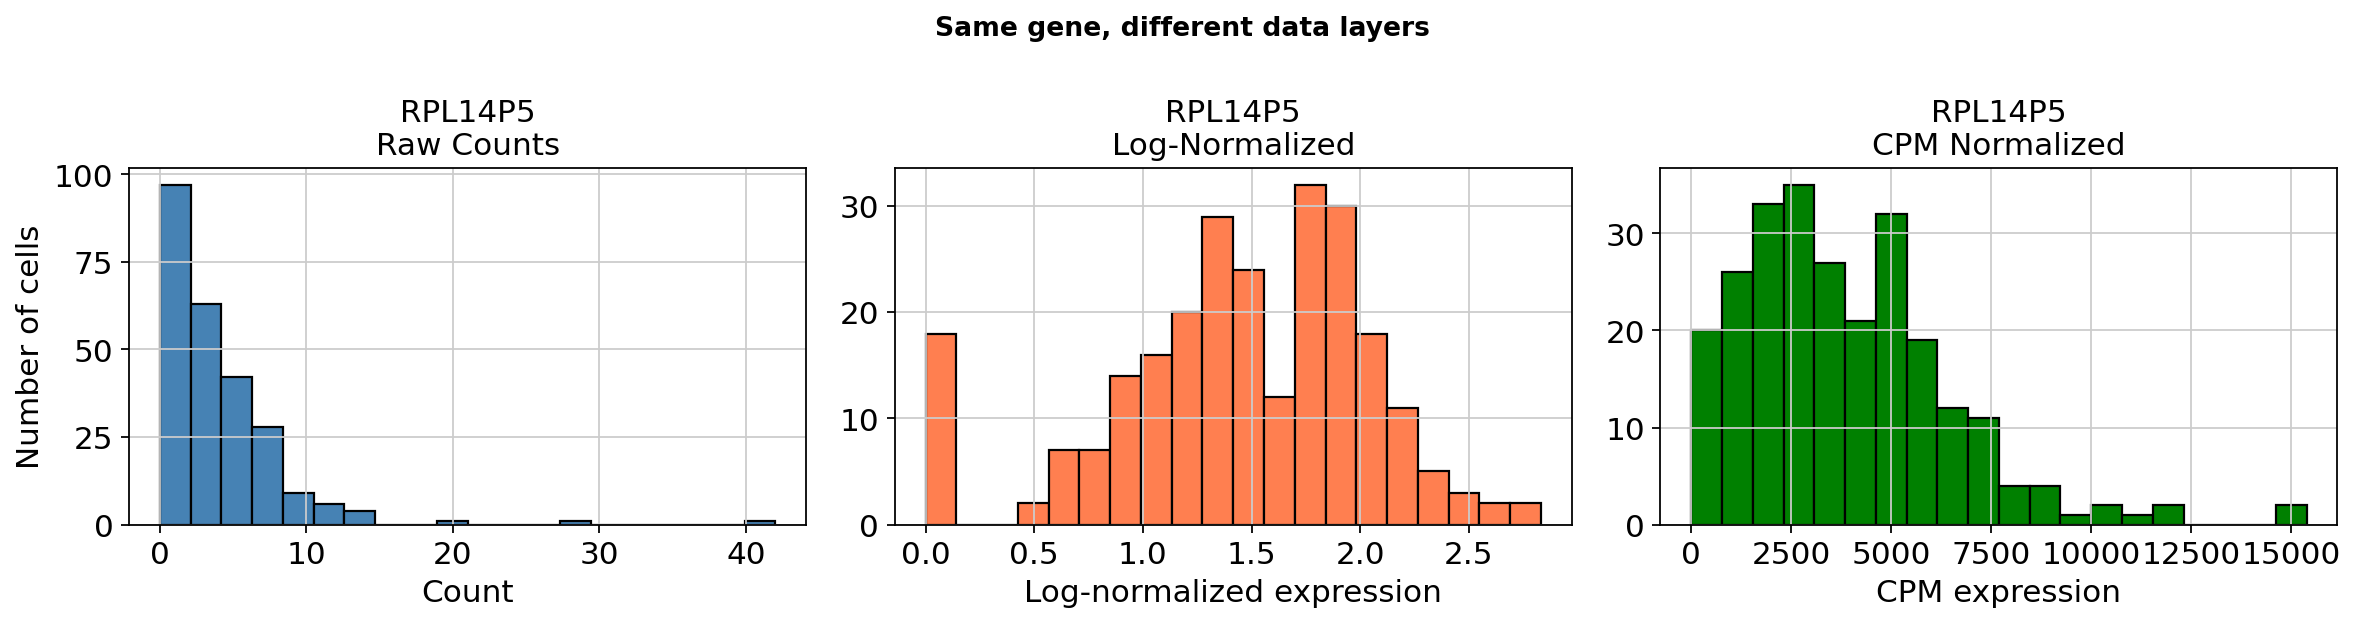

Plot saved as layers_comparison.png


In [23]:
# Visualize gene expression from different layers using scanpy
# Pick a gene that has reasonable expression
expressed_genes = adata.var_names[np.array(adata.X.sum(axis=0)).flatten() > 5].tolist()
plot_gene = expressed_genes[5] if len(expressed_genes) > 5 else adata.var_names[0]
print(f'Plotting expression of gene: {plot_gene}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw counts
raw_expr = np.array(adata.layers['counts'][:, adata.var_names.get_loc(plot_gene)].todense()).flatten()
axes[0].hist(raw_expr, bins=20, edgecolor='black', color='steelblue')
axes[0].set_title(f'{plot_gene}\nRaw Counts')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Number of cells')

# Log normalized
norm_expr = np.array(adata.X[:, adata.var_names.get_loc(plot_gene)].todense()).flatten()
axes[1].hist(norm_expr, bins=20, edgecolor='black', color='coral')
axes[1].set_title(f'{plot_gene}\nLog-Normalized')
axes[1].set_xlabel('Log-normalized expression')

# CPM
cpm_expr = np.array(adata.layers['counts_per_million'][:, adata.var_names.get_loc(plot_gene)].todense()).flatten()
axes[2].hist(cpm_expr, bins=20, edgecolor='black', color='green')
axes[2].set_title(f'{plot_gene}\nCPM Normalized')
axes[2].set_xlabel('CPM expression')

plt.suptitle('Same gene, different data layers', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('layers_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as layers_comparison.png')

## Step 9: Unstructured Metadata — `adata.uns`

`adata.uns` is a Python dictionary for **unstructured metadata** — anything that doesn't fit into obs, var, or obsm. This includes processing parameters, color palettes, and results from analysis tools.

In [24]:
# Inspect unstructured metadata
print('Unstructured metadata (adata.uns):')
print('Keys:', list(adata.uns.keys()))
print()

# Show contents of each uns key
for key in adata.uns:
    val = adata.uns[key]
    if isinstance(val, dict):
        print(f'  {key}: dict with keys {list(val.keys())}')
    elif isinstance(val, np.ndarray):
        print(f'  {key}: array shape {val.shape}')
    else:
        print(f'  {key}: {type(val).__name__}')

Unstructured metadata (adata.uns):
Keys: ['cell_type_colors', 'hvg', 'leiden_colors', 'leiden_res_0.10', 'leiden_res_0.10_colors', 'leiden_res_0.30', 'leiden_res_0.30_colors', 'leiden_res_0.50', 'leiden_res_0.50_colors', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rank_genes_groups', 'scrublet', 'umap']

  cell_type_colors: array shape (2,)
  hvg: dict with keys ['flavor']
  leiden_colors: array shape (2,)
  leiden_res_0.10: dict with keys ['modularity', 'params']
  leiden_res_0.10_colors: array shape (2,)
  leiden_res_0.30: dict with keys ['modularity', 'params']
  leiden_res_0.30_colors: array shape (2,)
  leiden_res_0.50: dict with keys ['modularity', 'params']
  leiden_res_0.50_colors: array shape (3,)
  log1p: dict with keys ['base']
  neighbors: dict with keys ['connectivities_key', 'distances_key', 'params']
  pca: dict with keys ['params', 'variance', 'variance_ratio']
  predicted_doublet_colors: array shape (2,)
  rank_genes_groups: dict with keys ['logfoldchange

In [25]:
# Add our own metadata to uns
adata.uns['project_info'] = {
    'project_name': 'scRNA-seq 10X Preprocessing Project',
    'dataset': '1k PBMC Healthy Donor (10X Genomics v3)',
    'genome': 'Human hg19 chrX',
    'part1_tool': 'RNA STARsolo + DropletUtils (Galaxy)',
    'part2_tool': 'Scanpy (Python)',
    'cells': adata.n_obs,
    'genes': adata.n_vars
}

print('Project info added to uns!')
print()
print('Project info:')
for k, v in adata.uns['project_info'].items():
    print(f'  {k}: {v}')

Project info added to uns!

Project info:
  project_name: scRNA-seq 10X Preprocessing Project
  dataset: 1k PBMC Healthy Donor (10X Genomics v3)
  genome: Human hg19 chrX
  part1_tool: RNA STARsolo + DropletUtils (Galaxy)
  part2_tool: Scanpy (Python)
  cells: 252
  genes: 751


## Step 10: Subsetting AnnData Objects

AnnData supports flexible subsetting by:
- **Name index** (cell barcodes or gene names)
- **Numerical index** (row/column numbers)
- **Boolean index** (True/False mask)

Subsetting always returns a **view** (not a copy) — efficient and memory-saving.

In [26]:
# 1. Subset by numerical index
adata_first5 = adata[:5, :10]
print('Subset: first 5 cells × first 10 genes')
print(f'  Type: {type(adata_first5)}')
print(f'  Shape: {adata_first5.shape}')
print(f'  Is view: {adata_first5.is_view}')

Subset: first 5 cells × first 10 genes
  Type: <class 'anndata._core.anndata.AnnData'>
  Shape: (5, 10)
  Is view: True


In [27]:
# 2. Subset by cell barcode names
selected_cells = adata.obs_names[:3].tolist()
adata_named = adata[selected_cells, :]
print(f'Subset by cell names: {selected_cells}')
print(f'Shape: {adata_named.shape}')

Subset by cell names: ['AAAGAACCAATGGCAG', 'AAAGGATAGTAGACAT', 'AAAGGATCACCGGCTA']
Shape: (3, 751)


In [28]:
# 3. Subset by boolean mask — keep only cluster '0' cells
mask_cluster0 = adata.obs['leiden'] == '0'
adata_cluster0 = adata[mask_cluster0, :]
print(f'Cluster 0 cells: {adata_cluster0.n_obs}')
print(f'Is view: {adata_cluster0.is_view}')

Cluster 0 cells: 173
Is view: True


In [29]:
# 4. Subset by boolean mask — keep only highly variable genes
hvg_mask = adata.var['highly_variable']
adata_hvg = adata[:, hvg_mask]
print(f'All cells × HVGs only: {adata_hvg.shape}')
print(f'Is view: {adata_hvg.is_view}')

All cells × HVGs only: (252, 500)
Is view: True


In [30]:
# 5. Combined subsetting — specific cell type + specific genes
cell_type_mask = adata.obs['cell_type'] == adata.obs['cell_type'].iloc[0]
gene_mask = adata.var['highly_variable']

adata_subset = adata[cell_type_mask, gene_mask]
cell_type_name = adata.obs['cell_type'].iloc[0]
print(f'Subset: {cell_type_name} cells × HVGs')
print(f'Shape: {adata_subset.shape}')
print(f'Is view: {adata_subset.is_view}')

Subset: T/NK Lymphocytes cells × HVGs
Shape: (173, 500)
Is view: True


## Step 11: Views vs Copies

- A **view** references the original data — no extra memory used, changes in parent propagate to view
- A **copy** is independent — uses extra memory, changes in parent do NOT propagate

Use `.copy()` when you want to modify a subset independently.

In [31]:
# Create a view
adata_view = adata[:10, :5]
print(f'View created: is_view = {adata_view.is_view}')
print(f'Shape: {adata_view.shape}')

View created: is_view = True
Shape: (10, 5)


In [32]:
# Create a copy from the view
adata_copy = adata_view.copy()
print(f'Copy created: is_view = {adata_copy.is_view}')
print(f'Shape: {adata_copy.shape}')
print()
print('The copy holds actual data independently from the parent AnnData!')

Copy created: is_view = False
Shape: (10, 5)

The copy holds actual data independently from the parent AnnData!


In [33]:
# Demonstrate: modifying a view converts it to a copy
adata_view2 = adata[:5, :3]
print(f'Before modification: is_view = {adata_view2.is_view}')

# Add a column to obs — this triggers conversion
adata_view2.obs['test_column'] = 'test'
print(f'After modification:  is_view = {adata_view2.is_view}')
print('(View was automatically converted to a copy!)')

Before modification: is_view = True
After modification:  is_view = False
(View was automatically converted to a copy!)


## Step 12: Cell-Cell Relationships — `adata.obsp`

`adata.obsp` stores **cell × cell matrices** such as k-nearest neighbor graphs and distance matrices. These are used in clustering and trajectory analysis.

In [34]:
# Inspect obsp
print('Cell-cell pair matrices (adata.obsp):')
for key in adata.obsp:
    matrix = adata.obsp[key]
    print(f'  {key}: shape={matrix.shape}, dtype={matrix.dtype}')

Cell-cell pair matrices (adata.obsp):
  connectivities: shape=(252, 252), dtype=float32
  distances: shape=(252, 252), dtype=float64


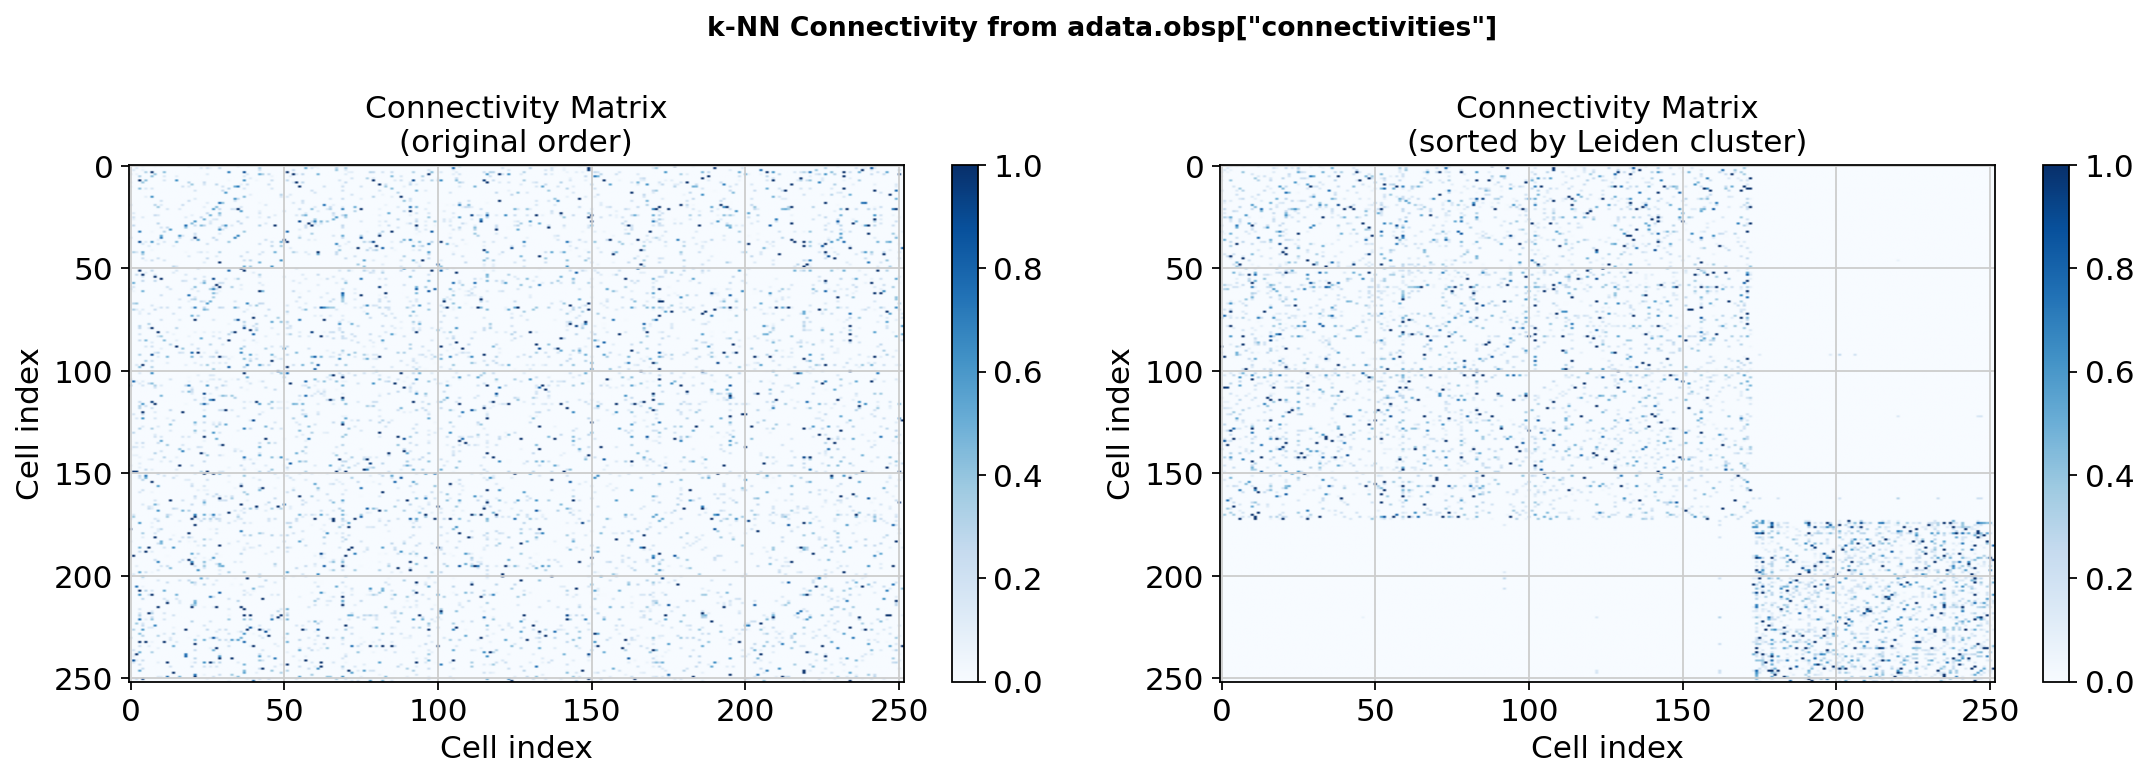

Plot saved as connectivity_matrix.png


In [35]:
# Visualize the neighborhood connectivity matrix
if 'connectivities' in adata.obsp:
    conn_matrix = adata.obsp['connectivities'].toarray()

    # Sort cells by cluster for better visualization
    cluster_order = np.argsort(adata.obs['leiden'].astype(int).values)
    conn_sorted = conn_matrix[cluster_order, :][:, cluster_order]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Unsorted
    axes[0].imshow(conn_matrix, cmap='Blues', aspect='auto')
    axes[0].set_title('Connectivity Matrix\n(original order)')
    axes[0].set_xlabel('Cell index')
    axes[0].set_ylabel('Cell index')
    plt.colorbar(axes[0].images[0], ax=axes[0])

    # Sorted by cluster
    axes[1].imshow(conn_sorted, cmap='Blues', aspect='auto')
    axes[1].set_title('Connectivity Matrix\n(sorted by Leiden cluster)')
    axes[1].set_xlabel('Cell index')
    axes[1].set_ylabel('Cell index')
    plt.colorbar(axes[1].images[0], ax=axes[1])

    plt.suptitle('k-NN Connectivity from adata.obsp["connectivities"]',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('connectivity_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved as connectivity_matrix.png')
else:
    print('No connectivities found in obsp.')
    print('Available keys:', list(adata.obsp.keys()))

## Step 13: Converting to DataFrames

AnnData can be converted to Pandas DataFrames for inspection or export.

In [36]:
# Convert log-normalized counts to DataFrame
# (use a small subset for display)
small_adata = adata[:5, :8]
df_normalized = small_adata.to_df()
print('Log-normalized expression as DataFrame (5 cells × 8 genes):')
print(df_normalized.round(3))

Log-normalized expression as DataFrame (5 cells × 8 genes):
                  PLCXD1  GTPBP6  LINC00685  PPP2R3B  SHOX  RPL14P5  CSF2RA  \
AAAGAACCAATGGCAG     0.0   0.000      0.000      0.0   0.0    2.832   0.000   
AAAGGATAGTAGACAT     0.0   0.528      0.000      0.0   0.0    2.306   0.000   
AAAGGATCACCGGCTA     0.0   0.000      0.000      0.0   0.0    1.545   0.000   
AAAGGATTCCGTTTCG     0.0   0.486      0.486      0.0   0.0    1.254   0.812   
AAAGTCCCACCAGCCA     0.0   0.387      0.000      0.0   0.0    1.345   0.387   

                  RN7SL355P  
AAAGAACCAATGGCAG        0.0  
AAAGGATAGTAGACAT        0.0  
AAAGGATCACCGGCTA        0.0  
AAAGGATTCCGTTTCG        0.0  
AAAGTCCCACCAGCCA        0.0  


In [37]:
# Convert raw counts layer to DataFrame
df_raw = small_adata.to_df(layer='counts')
print('Raw counts as DataFrame (5 cells × 8 genes):')
print(df_raw)

Raw counts as DataFrame (5 cells × 8 genes):
                  PLCXD1  GTPBP6  LINC00685  PPP2R3B  SHOX  RPL14P5  CSF2RA  \
AAAGAACCAATGGCAG       0       0          0        0     0        5       0   
AAAGGATAGTAGACAT       0       1          0        0     0       13       0   
AAAGGATCACCGGCTA       0       0          0        0     0        3       0   
AAAGGATTCCGTTTCG       0       1          1        0     0        4       2   
AAAGTCCCACCAGCCA       0       1          0        0     0        6       1   

                  RN7SL355P  
AAAGAACCAATGGCAG          0  
AAAGGATAGTAGACAT          0  
AAAGGATCACCGGCTA          0  
AAAGGATTCCGTTTCG          0  
AAAGTCCCACCAGCCA          0  


In [38]:
# Export cell annotations to CSV
adata.obs.to_csv('pbmc_cell_annotations.csv')
print('Cell annotations exported to pbmc_cell_annotations.csv')
print(f'Shape: {adata.obs.shape}')
print()
print('First few rows:')
print(adata.obs.head(3))

Cell annotations exported to pbmc_cell_annotations.csv
Shape: (252, 20)

First few rows:
                  n_genes_by_counts  log1p_n_genes_by_counts  total_counts  \
AAAGAACCAATGGCAG                105                 4.663439           326   
AAAGGATAGTAGACAT                152                 5.030438          1495   
AAAGGATCACCGGCTA                124                 4.828314           845   

                  log1p_total_counts  pct_counts_in_top_50_genes  \
AAAGAACCAATGGCAG            5.789960                   83.128834   
AAAGGATAGTAGACAT            7.310550                   90.702341   
AAAGGATCACCGGCTA            6.740519                   90.177515   

                  pct_counts_in_top_100_genes  pct_counts_in_top_200_genes  \
AAAGAACCAATGGCAG                    98.466258                        100.0   
AAAGGATAGTAGACAT                    96.521739                        100.0   
AAAGGATCACCGGCTA                    97.159763                        100.0   

            

## Step 14: Complete AnnData Structure Summary


In [39]:
# Complete summary of our AnnData object
print('=' * 60)
print('COMPLETE ANNDATA STRUCTURE SUMMARY')
print('=' * 60)
print(f'\nAnnData shape: {adata.shape} (cells × genes)')
print()
print('[ X ] — Active data matrix')
print(f'  Log-normalized counts | shape: {adata.X.shape} | sparse: {sp.issparse(adata.X)}')
print()
print('[ obs ] — Cell annotations (rows = cells)')
for col in adata.obs.columns:
    dtype = adata.obs[col].dtype
    print(f'  {col}: {dtype}')
print()
print('[ var ] — Gene annotations (rows = genes)')
for col in adata.var.columns:
    dtype = adata.var[col].dtype
    print(f'  {col}: {dtype}')
print()
print('[ obsm ] — Multi-dimensional cell embeddings')
for key in adata.obsm:
    print(f'  {key}: {adata.obsm[key].shape}')
print()
print('[ layers ] — Alternative data matrices')
for key in adata.layers:
    print(f'  {key}: {adata.layers[key].shape}')
print()
print('[ uns ] — Unstructured metadata')
for key in adata.uns:
    print(f'  {key}')
print()
print('[ obsp ] — Cell-cell pair matrices')
for key in adata.obsp:
    print(f'  {key}: {adata.obsp[key].shape}')

COMPLETE ANNDATA STRUCTURE SUMMARY

AnnData shape: (252, 751) (cells × genes)

[ X ] — Active data matrix
  Log-normalized counts | shape: (252, 751) | sparse: True

[ obs ] — Cell annotations (rows = cells)
  n_genes_by_counts: int32
  log1p_n_genes_by_counts: float64
  total_counts: int64
  log1p_total_counts: float64
  pct_counts_in_top_50_genes: float64
  pct_counts_in_top_100_genes: float64
  pct_counts_in_top_200_genes: float64
  pct_counts_in_top_500_genes: float64
  total_counts_ribo: int64
  log1p_total_counts_ribo: float64
  pct_counts_ribo: float64
  n_genes: int64
  doublet_score: float64
  predicted_doublet: bool
  leiden_res_0.10: category
  leiden_res_0.30: category
  leiden_res_0.50: category
  leiden: category
  cell_type: category
  high_ribo: bool

[ var ] — Gene annotations (rows = genes)
  gene_ids: object
  gene_names: category
  ribo: bool
  n_cells_by_counts: int64
  mean_counts: float64
  log1p_mean_counts: float64
  pct_dropout_by_counts: float64
  total_count

## Step 15: Writing the Final AnnData to Disk

We save the fully annotated AnnData object — now enriched with additional layers and metadata from Part 3.

In [40]:
# Save the enriched AnnData object
output_file = 'pbmc_chrX_final.h5ad'
adata.write_h5ad(output_file, compression='gzip')

import os
file_size = os.path.getsize(output_file) / (1024 * 1024)
print(f'Final AnnData saved to: {output_file}')
print(f'File size: {file_size:.2f} MB')
print()
print('This file contains the complete analysis pipeline output:')
print('  Part 1: Galaxy STARsolo + DropletUtils preprocessing')
print('  Part 2: Scanpy QC, normalization, clustering, annotation')
print('  Part 3: AnnData enrichment with CPM layer and project metadata')

Final AnnData saved to: pbmc_chrX_final.h5ad
File size: 1.07 MB

This file contains the complete analysis pipeline output:
  Part 1: Galaxy STARsolo + DropletUtils preprocessing
  Part 2: Scanpy QC, normalization, clustering, annotation
  Part 3: AnnData enrichment with CPM layer and project metadata


In [41]:
# Verify the saved file by reading it back
adata_check = ad.read_h5ad(output_file)
print('Verification - file read back successfully!')
print(adata_check)

Verification - file read back successfully!
AnnData object with n_obs × n_vars = 252 × 751
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.10', 'leiden_res_0.30', 'leiden_res_0.50', 'leiden', 'cell_type', 'high_ribo'
    var: 'gene_ids', 'gene_names', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'hvg', 'leiden_colors', 'leiden_res_0.10', 'leiden_res_0.10_colors', 'leiden_res_0.30', 'leiden_res_0.30_colors', 'leiden_res_0.50', 'leiden_res_0.50_colors', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'p

In [42]:
# Download files if on Google Colab
try:
    from google.colab import files
    files.download(output_file)
    files.download('pbmc_cell_annotations.csv')
    print('Files downloaded!')
except ImportError:
    print(f'Files saved locally:\n  - {output_file}\n  - pbmc_cell_annotations.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded!


## Conclusion

In this notebook we explored the **AnnData format** using our PBMC data from Parts 1 and 2:

| Component | What it stores | Our data |
|-----------|---------------|----------|
| `adata.X` | Active data matrix | Log-normalized counts |
| `adata.obs` | Cell metadata | Barcodes, QC metrics, clusters, cell types |
| `adata.var` | Gene metadata | Gene IDs, names, HVG flags |
| `adata.obsm` | Cell embeddings | X_pca, X_umap |
| `adata.layers` | Alternative matrices | Raw counts, log-normalized, CPM |
| `adata.uns` | Unstructured metadata | Analysis parameters, project info |
| `adata.obsp` | Cell-cell matrices | k-NN connectivities and distances |

### Complete Pipeline Summary
```
Part 1 (Galaxy)     → Raw FASTQ → Mapped reads → Count matrix (MTX format)
Part 2 (Scanpy)     → Count matrix → QC → Clustering → h5ad file
Part 3 (AnnData)    → h5ad exploration → Enriched h5ad file
```

AnnData is the **backbone of the entire scverse ecosystem** and understanding its structure is essential for all single-cell analyses in Python.
